# 01 · Análisis Exploratorio de Datos (EDA)
**Proyecto Final — Gestión de Datos · UAX**

---

> **Propósito:** Inventariar las 17 tablas del OLTP `saleshealth`, detectar anomalías
> (nulos, duplicados, inconsistencias referenciales, valores imposibles) y documentar
> las decisiones de imputación que justifican el ETL posterior.
>
> **Schema analizado:** `public` (OLTP — origen de datos)
> **Regla fundamental:** NUNCA se eliminan clientes. Los datos incorrectos o nulos se imputan.

---

| Sección | Contenido |
|---|---|
| 1 | Imports, paleta y conexión |
| 2 | Inventario general de tablas |
| 3 | Análisis de clientes (`customer`) |
| 4 | Análisis de ventas (`sale` + `sale_item`) |
| 5 | Análisis de productos (`product` + `central_product`) |
| 6 | Análisis de devoluciones (`return_item`) |
| 7 | Análisis de tiendas y geografía (`store` + `city_zone`) |
| 8 | Análisis de ofertas (`offer` + `product_offer`) |
| 9 | Análisis temporal para CLTV (parámetro R_t) |
| 10 | Tabla maestra de decisiones de imputación |

---
## Sección 1 — Imports, paleta y conexión

In [43]:
import sys
!{sys.executable} -m pip install psycopg2-binary sqlalchemy pandas matplotlib seaborn numpy --quiet

In [44]:
from pathlib import Path
GRAFICOS = Path('graficos')
GRAFICOS.mkdir(exist_ok=True)
print('✓ Carpeta graficos/ lista.')

✓ Carpeta graficos/ lista.


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text
import warnings
from datetime import date
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# ══════════════════════════════════════════════════════════════════════════
# PALETA FASE 1: EDA — Tonos Azules
# Esta paleta se usa en TODOS los gráficos de este notebook.
# ══════════════════════════════════════════════════════════════════════════
C1 = '#1B4F72'   # azul marino    — barras / elemento principal
C2 = '#2E86C1'   # azul medio     — comparaciones / segundo nivel
C3 = '#85C1E9'   # azul claro     — tercer nivel / relleno suave
C4 = '#E74C3C'   # rojo           — anomalías / NULLs / alertas
C5 = '#27AE60'   # verde          — valores OK / correctos
C6 = '#E67E22'   # naranja        — avisos / advertencias
C7 = '#7F8C8D'   # gris           — neutro / secundario

PALETTE_EDA = [C1, C2, C3, C7, C6, C4]
SEQ_CMAP    = 'Blues'
DIV_CMAP    = 'RdBu_r'

# Estilo global
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.figsize'   : (13, 5),
    'axes.titlesize'   : 14,
    'axes.labelsize'   : 12,
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

print('✓ Imports y paleta configurados.')

✓ Imports y paleta configurados.


In [46]:
# ── Conexión a PostgreSQL ─────────────────────────────────────────────────
HOST     = 'localhost'
PORT     = 5432
DB_NAME  = 'Proyecto_final'
USER     = 'admin'
PASSWORD = 'admin'   # ← cambia si es necesario

engine = create_engine(
    f'postgresql+psycopg2://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB_NAME}'
)

with engine.connect() as conn:
    ver = conn.execute(text('SELECT version()')).scalar()
    print(f'✓ Conexión establecida')
    print(f'  PostgreSQL: {ver[:60]}...')
    print(f'  Fecha de análisis: {date.today()}')

✓ Conexión establecida
  PostgreSQL: PostgreSQL 18.3 (Debian 18.3-1.pgdg13+1) on aarch64-unknown-...
  Fecha de análisis: 2026-05-01


---
## Sección 2 — Inventario general de tablas

Recorremos las 17 tablas del schema `public` y calculamos para cada una:
- Número de filas
- Número de columnas
- Si tiene al menos una columna con NULLs (→ barra en rojo en el gráfico)

In [47]:
TABLAS = [
    'brand', 'category', 'central_inventory', 'central_product',
    'city_zone', 'customer', 'inventory', 'offer', 'product',
    'product_offer', 'return_item', 'return_reason', 'sale',
    'sale_item', 'store', 'warehouse', 'warehouse_location'
]

inventario = []
with engine.connect() as conn:
    for tbl in TABLAS:
        n_rows = conn.execute(text(f'SELECT COUNT(*) FROM {tbl}')).scalar()
        cols_q = conn.execute(text(
            f"SELECT column_name FROM information_schema.columns "
            f"WHERE table_schema='public' AND table_name='{tbl}'"
        )).fetchall()
        n_cols = len(cols_q)
        col_names = [r[0] for r in cols_q]
        # Verificar si alguna columna tiene NULLs
        checks = ' + '.join([f'(COUNT(*) - COUNT({c}))' for c in col_names])
        total_nulls = conn.execute(text(f'SELECT {checks} FROM {tbl}')).scalar()
        inventario.append({
            'tabla'       : tbl,
            'filas'       : n_rows,
            'columnas'    : n_cols,
            'tiene_nulls' : (total_nulls > 0)
        })

df_inv = (pd.DataFrame(inventario)
            .sort_values('filas', ascending=False)
            .reset_index(drop=True))

display(df_inv.style
    .format({'filas': '{:,}'})
    .apply(lambda col: [
        'background-color: #FADBD8; color: #922B21' if v else ''
        for v in df_inv['tiene_nulls']
    ], subset=['tabla'])
    .set_caption('Inventario de tablas OLTP · Rojo = tablas con NULLs detectados')
    .hide(axis='index')
)

tabla,filas,columnas,tiene_nulls
sale_item,"42,555",7,True
sale,"20,000",5,False
customer,"5,750",7,False
return_item,"2,330",5,False
inventory,"1,000",5,False
product,50,6,False
central_inventory,49,8,False
central_product,49,8,False
city_zone,42,6,True
warehouse_location,40,6,False


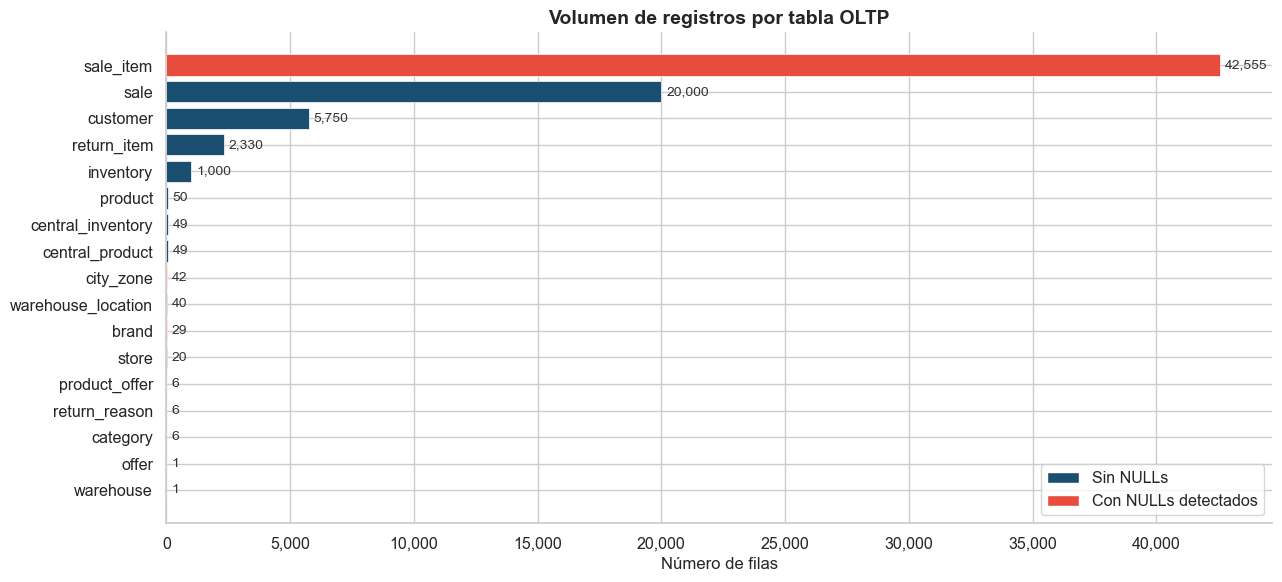


Tablas con NULLs: 3 de 17
    tabla  filas  columnas
sale_item  42555         7
city_zone     42         6
    brand     29         4


In [48]:
fig, ax = plt.subplots(figsize=(13, 6))

colores = [C4 if v else C1 for v in df_inv['tiene_nulls']]
bars = ax.barh(df_inv['tabla'], df_inv['filas'], color=colores, edgecolor='white', linewidth=0.5)

# Anotaciones de valor
for bar in bars:
    w = bar.get_width()
    ax.text(w + 200, bar.get_y() + bar.get_height() / 2,
            f'{int(w):,}', va='center', ha='left', fontsize=10, color='#333333')

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=C1, label='Sin NULLs'),
    Patch(facecolor=C4, label='Con NULLs detectados'),
]
ax.legend(handles=legend_elements, loc='lower right', frameon=True)

ax.set_xlabel('Número de filas')
ax.set_title('Volumen de registros por tabla OLTP', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('graficos/eda_inventario_tablas.png', dpi=150, bbox_inches='tight')
plt.show()

n_con_nulls = df_inv['tiene_nulls'].sum()
print(f'\nTablas con NULLs: {n_con_nulls} de {len(df_inv)}')
print(df_inv[df_inv['tiene_nulls']][['tabla', 'filas', 'columnas']].to_string(index=False))

---
## Sección 3 — Análisis de clientes (`customer`)

La tabla `customer` es la más importante del proyecto: de ella depende la segmentación CLTV.
Analizamos nulos, formato de email y teléfono, unicidad y el campo `created_at`
(que usaremos para calcular R_t en la fórmula CLTV).

In [49]:
df_customer = pd.read_sql('SELECT * FROM customer', engine)
df_customer['created_at'] = pd.to_datetime(df_customer['created_at'])

print(f'Filas: {len(df_customer):,}   Columnas: {df_customer.shape[1]}')
print(f'Columnas: {df_customer.columns.tolist()}')
print()
display(df_customer.head(3))
print()
print(df_customer.dtypes.rename('tipo'))

Filas: 5,750   Columnas: 7
Columnas: ['customer_id', 'first_name', 'last_name', 'last_name2', 'email', 'phone', 'created_at']



,customer_id,first_name,last_name,last_name2,email,phone,created_at
0,1,Marta,Ruiz,García,marta.ruiz1@example.com,+34 6987791,2018-11-15 04:51:29.131242
1,2,Alejandro,López,López,alejandro.lópez2@example.com,+34 669926134,2018-09-07 20:45:28.751233
2,3,Alejandro,López,Álvarez,alejandro.lópez3@example.com,+34 661558537,2019-02-09 06:54:03.656551



customer_id             int64
first_name             object
last_name              object
last_name2             object
email                  object
phone                  object
created_at     datetime64[ns]
Name: tipo, dtype: object


─── NULLs por columna ───


,nulos,% total
customer_id,0,0.00%
first_name,0,0.00%
last_name,0,0.00%
last_name2,0,0.00%
email,0,0.00%
phone,0,0.00%
created_at,0,0.00%


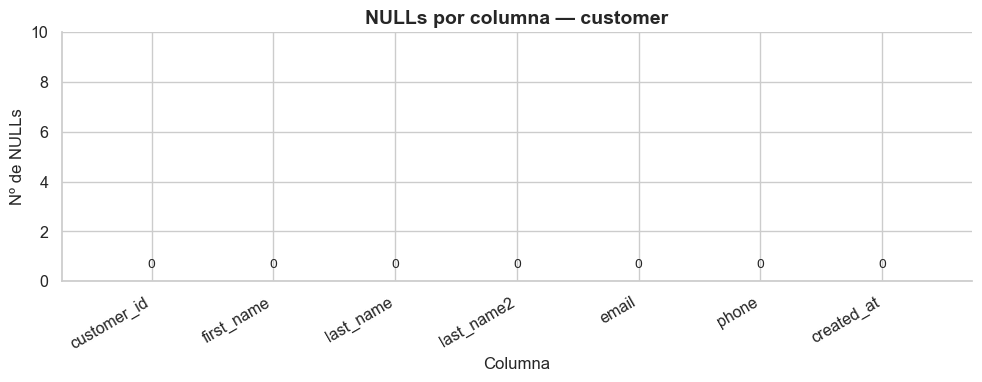

In [50]:
nulls = df_customer.isnull().sum()
pct   = (nulls / len(df_customer) * 100).round(2)
df_nulls = pd.DataFrame({'nulos': nulls, '% total': pct})

print('─── NULLs por columna ───')
display(df_nulls.style
    .format({'% total': '{:.2f}%'})
    .apply(lambda col: [
        'background-color: #FADBD8; color: #C0392B' if v > 0 else 'background-color: #EAFAF1'
        for v in nulls
    ], subset=['nulos'])
    .set_caption('Análisis de NULLs — tabla customer')
)

# Barplot de NULLs
fig, ax = plt.subplots(figsize=(10, 4))
colores_null = [C4 if v > 0 else C5 for v in nulls.values]
bars = ax.bar(nulls.index, nulls.values, color=colores_null, edgecolor='white')

# Posición del texto: usar offset relativo al rango del eje, no absoluto
y_offset = max(nulls.max() * 0.03, 0.4)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + y_offset,
            str(int(h)), ha='center', va='bottom', fontsize=10)

ax.set_title('NULLs por columna — customer', fontweight='bold')
ax.set_xlabel('Columna')
ax.set_ylabel('Nº de NULLs')
ax.set_ylim(bottom=0, top=max(nulls.max() * 1.4 + 1, 10))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('graficos/eda_customer_nulls.png', dpi=150, bbox_inches='tight')
plt.show()

In [51]:
# Distribución de columnas categóricas disponibles en customer
cols_categoricas = ['gender', 'city', 'country'] 
cols_presentes   = [c for c in cols_categoricas if c in df_customer.columns]

if cols_presentes:
    for col in cols_presentes:
        dist = df_customer[col].value_counts(dropna=False)
        print(f'Distribución de {col}:')
        for val, n in dist.items():
            print(f'  {str(val):<20} {n:>5,}  ({n/len(df_customer)*100:.1f}%)')
        print()
else:
    print('La tabla customer no tiene columnas categóricas demográficas (gender, city, country).')
    print(f'Columnas disponibles: {df_customer.columns.tolist()}')

La tabla customer no tiene columnas categóricas demográficas (gender, city, country).
Columnas disponibles: ['customer_id', 'first_name', 'last_name', 'last_name2', 'email', 'phone', 'created_at']


In [52]:
# ── Análisis de emails ────────────────────────────────────────────────
# Problema conocido: apellidos compuestos ('Del Río', 'De la Hoz') generan
# espacios en el email construido automáticamente → email técnicamente inválido.

mask_null   = df_customer['email'].isna()
mask_spaces = df_customer['email'].str.contains(r'\s', na=False)
mask_no_at  = df_customer['email'].notna() & ~df_customer['email'].str.contains('@', na=False)

print(f'Emails NULL:             {mask_null.sum()}')
print(f'Emails con espacios:     {mask_spaces.sum()}  ← apellidos compuestos')
print(f'Emails sin @:            {mask_no_at.sum()}')
print()
if mask_spaces.sum() > 0:
    print('Ejemplos de emails con espacios:')
    display(df_customer[mask_spaces][['customer_id', 'first_name', 'last_name', 'email']].head(5))
    print()
    print('→ Decisión ETL: eliminar espacios del email (strip + replace " " → "")')

Emails NULL:             0
Emails con espacios:     98  ← apellidos compuestos
Emails sin @:            0

Ejemplos de emails con espacios:


,customer_id,first_name,last_name,email
757,758,Félix,Del Río,félix.del río_6@example.com
781,782,Biel,Del Río,biel.del río_30@example.com
786,787,Héctor,Del Río,héctor.del río_35@example.com
861,862,Dario,Del Río,dario.del río_110@example.com
902,903,Mireia,Del Río,mireia.del río_151@example.com



→ Decisión ETL: eliminar espacios del email (strip + replace " " → "")


In [53]:
# ── Análisis de teléfonos ─────────────────────────────────────────────
df_tel = df_customer[df_customer['phone'].notna()].copy()
df_tel['tel_limpio'] = df_tel['phone'].str.replace(r'[\s\-\+\(\)]', '', regex=True)
df_tel['tel_len']    = df_tel['tel_limpio'].str.len()

resumen_tel = df_tel['tel_len'].value_counts().sort_index().reset_index()
resumen_tel.columns = ['longitud', 'clientes']
resumen_tel['% total'] = (resumen_tel['clientes'] / len(df_customer) * 100).round(2)

print('Distribución de longitudes de teléfono (sin prefijos y separadores):')
display(resumen_tel)

# Longitud estándar española: 9 dígitos (sin prefijo +34)
n_no_estandar = df_tel[df_tel['tel_len'] != 9].shape[0]
print(f'\nTeléfonos con longitud ≠ 9 dígitos: {n_no_estandar}')
if n_no_estandar > 0:
    print('  → Son números con prefijo +34 incluido (11 dígitos) o números cortos.')
    print('  → Se documentan pero no se corrigen en el ETL (el campo es texto).')

Distribución de longitudes de teléfono (sin prefijos y separadores):


,longitud,clientes,% total
0,8,4,0.07
1,9,47,0.82
2,10,517,8.99
3,11,5182,90.12



Teléfonos con longitud ≠ 9 dígitos: 5703
  → Son números con prefijo +34 incluido (11 dígitos) o números cortos.
  → Se documentan pero no se corrigen en el ETL (el campo es texto).


Rango de created_at: 2018-01-01 → 2026-04-06
Clientes con created_at > 2025-12-30 (fecha futura): 5,000 (87.0%)


,customer_id,first_name,last_name,created_at
445,1190,Teo,Keller,2026-04-04 14:00:45.206380
751,1753,Gregorio,Atienza,2026-04-04 20:42:35.812025
752,753,Iris,Orozco,2026-04-04 14:00:45.206380
753,754,Valeria,Burgos,2026-04-04 14:00:45.206380


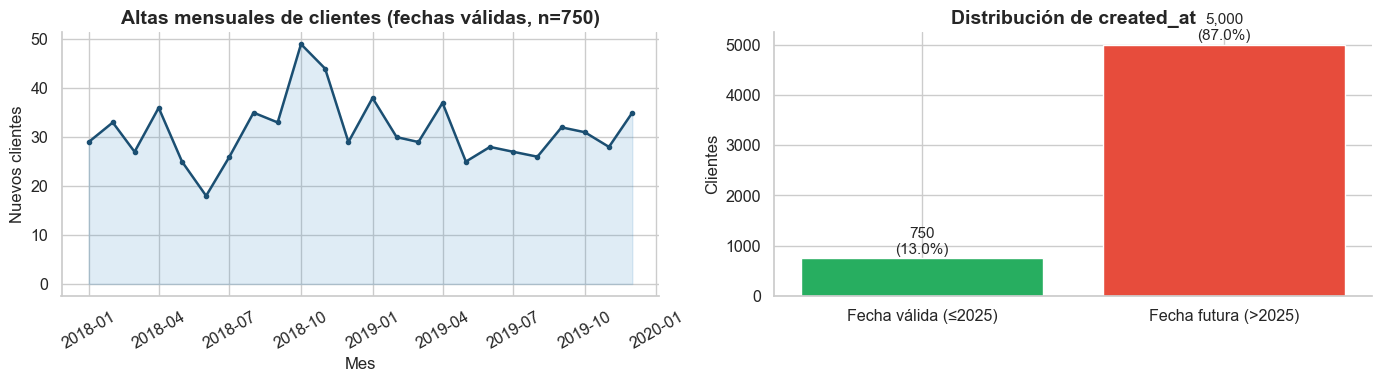

In [54]:
# ── Análisis de created_at ────────────────────────────────────────────
FECHA_REF = pd.Timestamp('2025-12-30')

mask_futuro = df_customer['created_at'] > FECHA_REF
n_futuro    = mask_futuro.sum()
pct_futuro  = n_futuro / len(df_customer) * 100

print(f'Rango de created_at: {df_customer["created_at"].min().date()} → {df_customer["created_at"].max().date()}')
print(f'Clientes con created_at > 2025-12-30 (fecha futura): {n_futuro:,} ({pct_futuro:.1f}%)')

if n_futuro > 0:
    display(df_customer[mask_futuro][['customer_id', 'first_name', 'last_name', 'created_at']].head(4))

# Serie mensual de altas (solo clientes con fecha válida)
df_validos = df_customer[~mask_futuro].copy()
altas_mes  = df_validos.set_index('created_at').resample('MS').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Gráfico 1: serie temporal de altas
axes[0].plot(altas_mes.index, altas_mes.values, color=C1, linewidth=1.8, marker='o', markersize=3)
axes[0].fill_between(altas_mes.index, altas_mes.values, alpha=0.15, color=C2)
axes[0].set_title(f'Altas mensuales de clientes (fechas válidas, n={len(df_validos):,})', fontweight='bold')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Nuevos clientes')
axes[0].tick_params(axis='x', rotation=30)

# Gráfico 2: clientes válidos vs futuro
labels = ['Fecha válida (≤2025)', 'Fecha futura (>2025)']
sizes  = [len(df_customer) - n_futuro, n_futuro]
axes[1].bar(labels, sizes, color=[C5, C4], edgecolor='white')
for i, (label, v) in enumerate(zip(labels, sizes)):
    axes[1].text(i, v + 30, f'{v:,}\n({v/len(df_customer)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11)
axes[1].set_title('Distribución de created_at', fontweight='bold')
axes[1].set_ylabel('Clientes')

plt.tight_layout()
plt.savefig('graficos/eda_customer_created_at.png', dpi=150, bbox_inches='tight')
plt.show()

In [55]:
# ── Verificación de unicidad ──────────────────────────────────────────
dup_id    = df_customer['customer_id'].duplicated().sum()
dup_email = df_customer['email'].notna() & df_customer.duplicated(subset='email', keep=False)
dup_nombre = df_customer.duplicated(subset=['first_name', 'last_name'], keep=False).sum()

print('Verificación de unicidad:')
print(f'  customer_id duplicados:          {dup_id}')
print(f'  Emails duplicados:               {dup_email.sum()}')
print(f'  Nombre+apellido duplicados:      {dup_nombre}  (normal: coincidencias de nombre)')

if dup_id == 0 and dup_email.sum() == 0:
    print()
    print('✓ customer_id es clave primaria correcta.')
    print('✓ No hay emails duplicados → unicidad de cliente por email garantizada.')

Verificación de unicidad:
  customer_id duplicados:          0
  Emails duplicados:               0
  Nombre+apellido duplicados:      2930  (normal: coincidencias de nombre)

✓ customer_id es clave primaria correcta.
✓ No hay emails duplicados → unicidad de cliente por email garantizada.


### Decisiones documentadas — `customer`

| Campo | Problema detectado | Nº registros | Decisión de imputación |
|---|---|---|---|
| `email` | NULL | *ver celda* | `cliente_<ID>@unknown.com` |
| `first_name` / `last_name` | NULL | *ver celda* | `"Desconocido"` |
| `phone` | NULL | *ver celda* | `"000000000"` |
| `email` | Espacios (apellidos compuestos) | ~98 | Eliminar espacios en ETL |
| `created_at` | Fechas futuras > 2025-12-30 | ~5.000 | Usar `first_purchase_date` para R_t (ver Sección 9) |

---
## Sección 4 — Análisis de ventas (`sale` + `sale_item`)

Verificamos la integridad de las ventas: coherencia de totales, rango temporal,
distribución de precios y el estado del campo `offer_id`.

In [56]:
df_sale      = pd.read_sql('SELECT * FROM sale', engine)
df_sale_item = pd.read_sql('SELECT * FROM sale_item', engine)
df_sale['sale_date'] = pd.to_datetime(df_sale['sale_date'])

# Resumen de shape y NULLs
for nombre, df in [('sale', df_sale), ('sale_item', df_sale_item)]:
    nulls = df.isnull().sum()
    print(f'── {nombre} ({len(df):,} filas × {df.shape[1]} cols) ──')
    print(nulls[nulls > 0].rename('NULLs') if nulls.sum() > 0 else '  Sin NULLs')
    print()

── sale (20,000 filas × 5 cols) ──
  Sin NULLs

── sale_item (42,555 filas × 7 cols) ──
offer_id    42547
Name: NULLs, dtype: int64



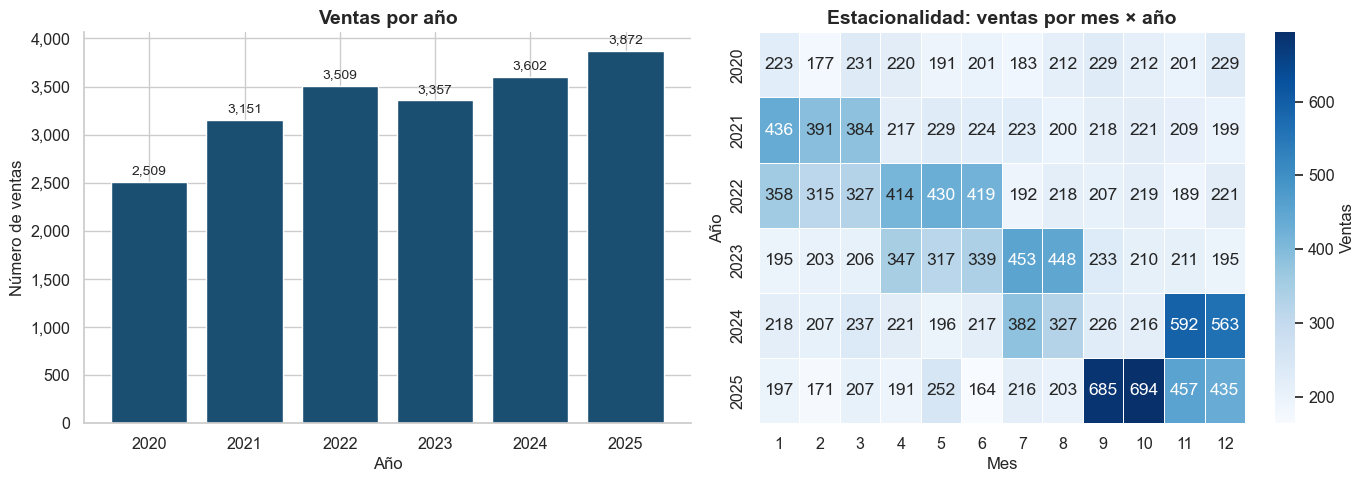

In [57]:
# ── Distribución temporal de ventas ──────────────────────────────────
df_sale['anyo'] = df_sale['sale_date'].dt.year
df_sale['mes']  = df_sale['sale_date'].dt.month

ventas_anyo = df_sale['anyo'].value_counts().sort_index()
pivot_calor = df_sale.groupby(['anyo', 'mes']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: ventas por año
bars = axes[0].bar(ventas_anyo.index, ventas_anyo.values, color=C1, edgecolor='white')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=10)
axes[0].set_title('Ventas por año', fontweight='bold')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Número de ventas')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Gráfico 2: heatmap mes × año (estacionalidad)
sns.heatmap(pivot_calor, ax=axes[1], cmap=SEQ_CMAP, fmt='d', annot=True,
            linewidths=0.5, cbar_kws={'label': 'Ventas'})
axes[1].set_title('Estacionalidad: ventas por mes × año', fontweight='bold')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Año')

plt.tight_layout()
plt.savefig('graficos/eda_ventas_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

In [58]:
# ── Integridad referencial ────────────────────────────────────────────
ids_sale     = set(df_sale['sale_id'].unique())
ids_customer = set(df_customer['customer_id'].unique())

# sale_item → sale
huerfanos_sale = set(df_sale_item['sale_id'].unique()) - ids_sale
# sale → customer
huerfanos_cust = set(df_sale['customer_id'].unique()) - ids_customer

print('Integridad referencial:')
print(f'  sale_item → sale:    {len(huerfanos_sale)} IDs huérfanos')
print(f'  sale → customer:     {len(huerfanos_cust)} IDs huérfanos')

if len(huerfanos_sale) == 0 and len(huerfanos_cust) == 0:
    print()
    print('✓ Integridad referencial correcta en ambos sentidos.')

Integridad referencial:
  sale_item → sale:    0 IDs huérfanos
  sale → customer:     0 IDs huérfanos

✓ Integridad referencial correcta en ambos sentidos.


Ventas con discrepancia entre total y suma de líneas: 1


,sale_id,total,subtotal_calculado,diferencia
18054,13009,324.77,321.77,3.00



→ Decisión ETL: flag total_corrected = TRUE para estas ventas en fact_sales.
  El total correcto es la suma de líneas (sale_item.subtotal).


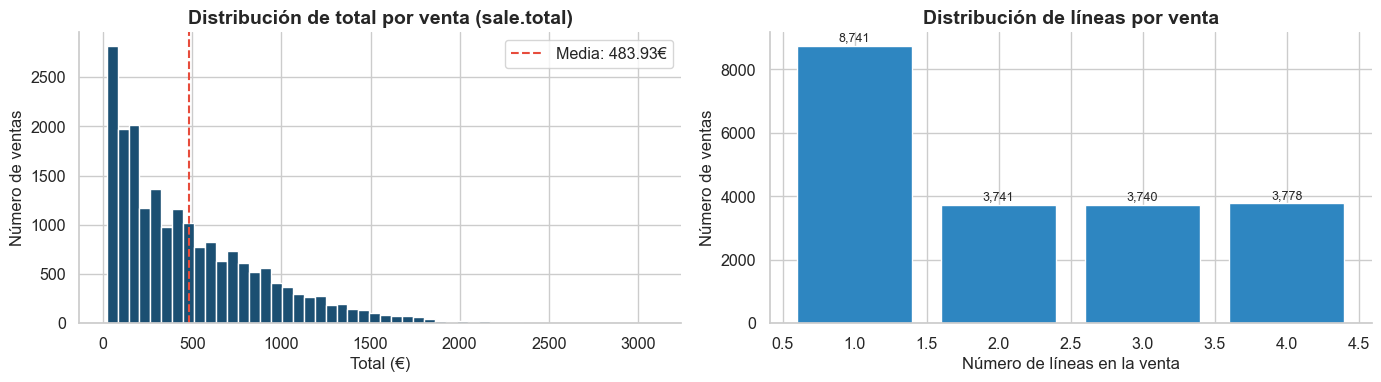

In [59]:
# ── Verificación de totales: sale.total vs suma de sale_item.subtotal ──
suma_items  = df_sale_item.groupby('sale_id')['subtotal'].sum().reset_index()
suma_items.columns = ['sale_id', 'subtotal_calculado']

df_check = df_sale[['sale_id', 'total']].merge(suma_items, on='sale_id', how='left')
df_check['diferencia'] = (df_check['total'] - df_check['subtotal_calculado']).abs().round(2)

discrepancias = df_check[df_check['diferencia'] > 0.01]
print(f'Ventas con discrepancia entre total y suma de líneas: {len(discrepancias)}')

if len(discrepancias) > 0:
    display(discrepancias.head(10))
    print()
    print('→ Decisión ETL: flag total_corrected = TRUE para estas ventas en fact_sales.')
    print('  El total correcto es la suma de líneas (sale_item.subtotal).')

# Distribución del total_amount
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_sale['total'].dropna(), bins=50, color=C1, edgecolor='white')
axes[0].set_title('Distribución de total por venta (sale.total)', fontweight='bold')
axes[0].set_xlabel('Total (€)')
axes[0].set_ylabel('Número de ventas')
media = df_sale['total'].mean()
axes[0].axvline(media, color=C4, linestyle='--', linewidth=1.5, label=f'Media: {media:.2f}€')
axes[0].legend()

# Líneas por venta
lineas_por_venta = df_sale_item.groupby('sale_id').size().value_counts().sort_index()
axes[1].bar(lineas_por_venta.index, lineas_por_venta.values, color=C2, edgecolor='white')
for i, (k, v) in enumerate(zip(lineas_por_venta.index, lineas_por_venta.values)):
    axes[1].text(k, v + 50, f'{v:,}', ha='center', va='bottom', fontsize=9)
axes[1].set_title('Distribución de líneas por venta', fontweight='bold')
axes[1].set_xlabel('Número de líneas en la venta')
axes[1].set_ylabel('Número de ventas')

plt.tight_layout()
plt.savefig('graficos/eda_ventas_totales.png', dpi=150, bbox_inches='tight')
plt.show()

In [60]:
# ── Análisis de quantity y unit_price ────────────────────────────────
print('Estadísticas descriptivas — sale_item:')
display(df_sale_item[['quantity', 'unit_price', 'subtotal']].describe().round(2))

print(f'\nValores negativos o cero:')
print(f'  quantity  ≤ 0: {(df_sale_item["quantity"] <= 0).sum()}')
print(f'  unit_price ≤ 0: {(df_sale_item["unit_price"] <= 0).sum()}')
print(f'  subtotal   ≤ 0: {(df_sale_item["subtotal"] <= 0).sum()}')

# Verificar coherencia: quantity × unit_price ≈ subtotal
df_sale_item['sub_calc'] = (df_sale_item['quantity'] * df_sale_item['unit_price']).round(2)
sub_diff = (df_sale_item['subtotal'] - df_sale_item['sub_calc']).abs()
inconsistencias_sub = (sub_diff > 0.02).sum()
print(f'  quantity × unit_price ≠ subtotal (|diff|>0.02): {inconsistencias_sub}')

if inconsistencias_sub == 0:
    print('✓ subtotal = quantity × unit_price en todas las líneas.')

Estadísticas descriptivas — sale_item:


,quantity,unit_price,subtotal
count,42555.00,42555.00,42555.00
mean,1.92,118.49,227.44
std,0.82,87.76,206.47
min,1.00,19.99,19.99
25%,1.00,49.99,79.99
50%,2.00,89.99,159.98
75%,3.00,149.99,299.98
max,3.00,399.99,1199.97



Valores negativos o cero:
  quantity  ≤ 0: 0
  unit_price ≤ 0: 0
  subtotal   ≤ 0: 0
  quantity × unit_price ≠ subtotal (|diff|>0.02): 8


offer_id en sale_item:
  NULL (sin oferta):   42,547 (100.0%)
  No NULL (con oferta):8 (0.02%)


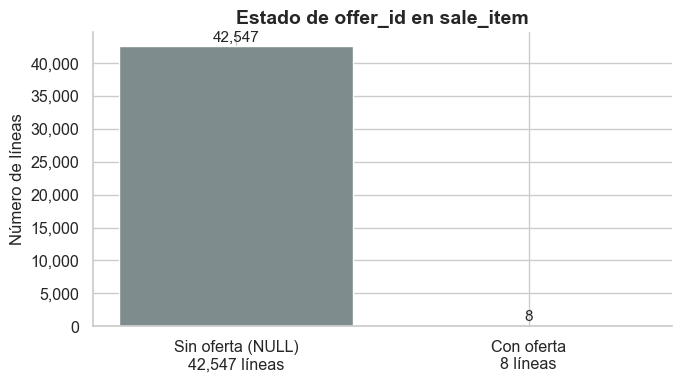


→ Decisión ETL: offer_id NULL → FK apunta a fila centinela offer_id = -1 ("Sin oferta")


In [61]:
# ── Análisis de offer_id en sale_item ────────────────────────────────
n_null_offer    = df_sale_item['offer_id'].isna().sum()
n_con_offer     = df_sale_item['offer_id'].notna().sum()
pct_null_offer  = n_null_offer / len(df_sale_item) * 100

print(f'offer_id en sale_item:')
print(f'  NULL (sin oferta):   {n_null_offer:,} ({pct_null_offer:.1f}%)')
print(f'  No NULL (con oferta):{n_con_offer:,} ({100-pct_null_offer:.2f}%)')

fig, ax = plt.subplots(figsize=(7, 4))
labels  = [f'Sin oferta (NULL)\n{n_null_offer:,} líneas', f'Con oferta\n{n_con_offer} líneas']
sizes   = [n_null_offer, n_con_offer]
bars    = ax.bar(labels, sizes, color=[C7, C2], edgecolor='white')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=11)
ax.set_title('Estado de offer_id en sale_item', fontweight='bold')
ax.set_ylabel('Número de líneas')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('graficos/eda_sale_offer_id.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('→ Decisión ETL: offer_id NULL → FK apunta a fila centinela offer_id = -1 ("Sin oferta")')

### Decisiones documentadas — `sale` + `sale_item`

| Campo | Problema detectado | Nº registros | Decisión de imputación |
|---|---|---|---|
| `sale_item.offer_id` | 100% NULL | ~42.547 | FK → fila centinela `offer_id = -1` en `dim_offer` |
| `sale.total` (id=13009) | Discrepancia de 3 € con suma de líneas | 1 | Flag `total_corrected = TRUE` en `fact_sales` |

---
## Sección 5 — Análisis de productos (`product` + `central_product`)

`product` tiene el catálogo de tienda (precio de venta) y `central_product` tiene
el coste unitario. Para calcular el margen hay que cruzarlas.
Analizamos qué clave es la mejor para el join y detectamos el producto sin coste.

In [62]:
df_product  = pd.read_sql('SELECT * FROM product', engine)
df_cprod    = pd.read_sql('SELECT * FROM central_product', engine)
df_brand    = pd.read_sql('SELECT * FROM brand', engine)
df_category = pd.read_sql('SELECT * FROM category', engine)

print(f'product:         {len(df_product):,} filas × {df_product.shape[1]} cols')
print(f'central_product: {len(df_cprod):,} filas × {df_cprod.shape[1]} cols')
print()

# NULLs
for nombre, df in [('product', df_product), ('central_product', df_cprod)]:
    nulls = df.isnull().sum()
    n_nulls = nulls.sum()
    print(f'{nombre}: {"Sin NULLs" if n_nulls == 0 else nulls[nulls>0].to_string()}')

product:         50 filas × 6 cols
central_product: 49 filas × 8 cols

product: Sin NULLs
central_product: Sin NULLs


In [63]:
# ── Match product ↔ central_product ──────────────────────────────────
# Estrategia 1: product_id directo
ids_p  = set(df_product['product_id'])
ids_cp = set(df_cprod['product_id'])
match_id = len(ids_p & ids_cp)

# Estrategia 2: nombre normalizado (fallback)
df_product['name_norm'] = df_product['name'].str.strip().str.lower()
df_cprod['name_norm']   = df_cprod['name'].str.strip().str.lower()
merge_nom = df_product.merge(df_cprod[['name_norm', 'unit_cost']], on='name_norm', how='left')
match_nom = merge_nom['unit_cost'].notna().sum()

print(f'Match por product_id directa:    {match_id} / {len(df_product)} productos')
print(f'Match por nombre normalizado:    {match_nom} / {len(df_product)} productos')
print()

# Identificar el producto sin match
merge_id = df_product.merge(
    df_cprod[['product_id', 'unit_cost', 'unit_price']],
    on='product_id', how='left', suffixes=('', '_cp')
)
sin_coste = merge_id[merge_id['unit_cost'].isna()]

print(f'Producto(s) sin unit_cost:')
display(sin_coste[['product_id', 'name', 'category', 'manufacturer', 'price']])

# Calcular mediana global para imputar
mediana_global = df_cprod['unit_cost'].median()
print(f'\nMediana global de unit_cost: {mediana_global:.2f} €')
print(f'→ Decisión ETL: imputar unit_cost del producto sin coste con esta mediana.')

Match por product_id directa:    49 / 50 productos
Match por nombre normalizado:    49 / 50 productos

Producto(s) sin unit_cost:


,product_id,name,category,manufacturer,price
28,29,Sensor temperatura inteligente,Domótica Salud,Xiaomi,19.99



Mediana global de unit_cost: 59.94 €
→ Decisión ETL: imputar unit_cost del producto sin coste con esta mediana.


In [64]:
# ── Validación de categoría ───────────────────────────────────────────
cats_validas = df_category['name'].str.lower().str.strip().tolist()
df_product['cat_norm'] = df_product['category'].str.lower().str.strip()
mask_cat_inv = ~df_product['cat_norm'].isin(cats_validas)

print(f'Categorías válidas: {df_category["name"].tolist()}')
print(f'\nProductos con categoría inválida: {mask_cat_inv.sum()}')
if mask_cat_inv.sum() > 0:
    display(df_product[mask_cat_inv][['product_id', 'name', 'category']])
    print()
    print('→ "Domótica Salud" no existe en la tabla category.')
    print('  Corrección ETL: asignar category = "Diagnóstico" para product_id=29.')
df_product.drop(columns=['cat_norm'], inplace=True)

Categorías válidas: ['Diagnóstico', 'Wellness', 'Movilidad', 'Rehabilitación', 'Higiene', 'Tratamiento']

Productos con categoría inválida: 1


,product_id,name,category
28,29,Sensor temperatura inteligente,Domótica Salud



→ "Domótica Salud" no existe en la tabla category.
  Corrección ETL: asignar category = "Diagnóstico" para product_id=29.


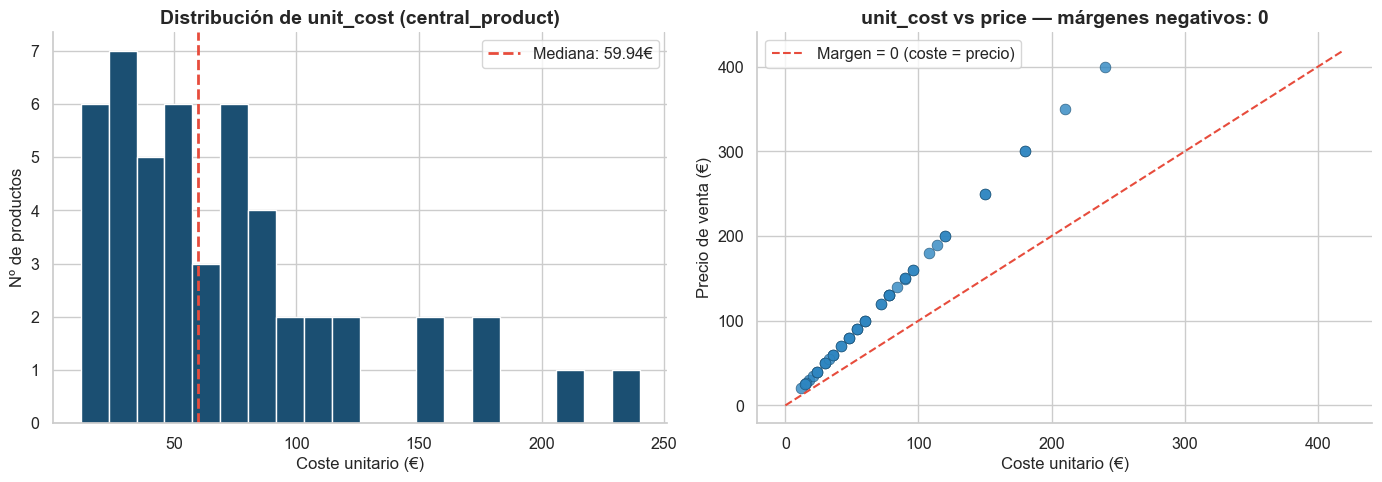

In [65]:
# ── Distribución de unit_cost y análisis de márgenes ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma unit_cost
axes[0].hist(df_cprod['unit_cost'].dropna(), bins=20, color=C1, edgecolor='white')
axes[0].axvline(mediana_global, color=C4, linestyle='--', linewidth=2,
                label=f'Mediana: {mediana_global:.2f}€')
axes[0].set_title('Distribución de unit_cost (central_product)', fontweight='bold')
axes[0].set_xlabel('Coste unitario (€)')
axes[0].set_ylabel('Nº de productos')
axes[0].legend()

# Scatter unit_cost vs unit_price
merge_valido = merge_id.dropna(subset=['unit_cost'])
axes[1].scatter(merge_valido['unit_cost'], merge_valido['price'],
                color=C2, alpha=0.8, edgecolors=C1, linewidths=0.5, s=60)
# Línea de margen cero: y = x
max_val = max(merge_valido['unit_cost'].max(), merge_valido['price'].max()) * 1.05
axes[1].plot([0, max_val], [0, max_val], color=C4, linestyle='--',
             linewidth=1.5, label='Margen = 0 (coste = precio)')
axes[1].set_title('unit_cost vs price (márgenes)', fontweight='bold')
axes[1].set_xlabel('Coste unitario (€)')
axes[1].set_ylabel('Precio de venta (€)')
axes[1].legend()

# Verificar que todos los márgenes son positivos
margenes_neg = (merge_valido['unit_cost'] > merge_valido['price']).sum()
axes[1].set_title(f'unit_cost vs price — márgenes negativos: {margenes_neg}', fontweight='bold')

plt.tight_layout()
plt.savefig('graficos/eda_productos_costes.png', dpi=150, bbox_inches='tight')
plt.show()

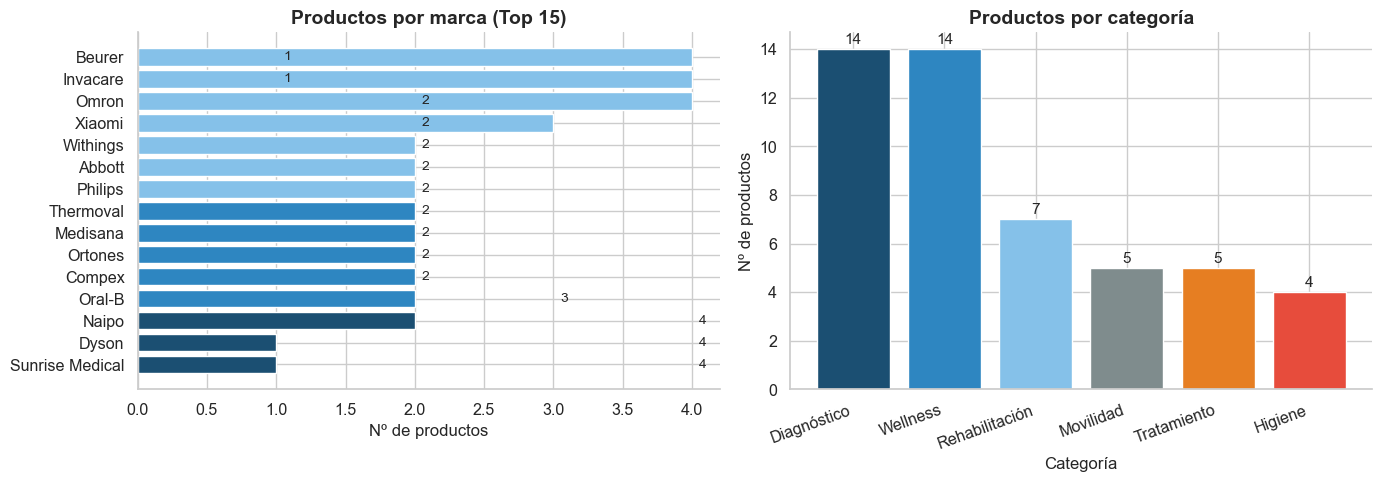

In [66]:
# ── Distribución por marca y categoría ───────────────────────────────
df_cprod_full = df_cprod.merge(df_brand.rename(columns={'name': 'brand_name'}), on='brand_id', how='left')
df_cprod_full = df_cprod_full.merge(df_category.rename(columns={'name': 'cat_name'}), on='category_id', how='left')

by_brand = df_cprod_full['brand_name'].value_counts().head(15)
by_cat   = df_cprod_full['cat_name'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Por marca
colors_brand = [C1 if i < 3 else C2 if i < 8 else C3 for i in range(len(by_brand))]
axes[0].barh(by_brand.index, by_brand.values, color=colors_brand[::-1], edgecolor='white')
for i, v in enumerate(by_brand.values[::-1]):
    axes[0].text(v + 0.05, i, str(v), va='center', fontsize=10)
axes[0].set_title('Productos por marca (Top 15)', fontweight='bold')
axes[0].set_xlabel('Nº de productos')
axes[0].invert_yaxis()

# Por categoría
colors_cat = [PALETTE_EDA[i % len(PALETTE_EDA)] for i in range(len(by_cat))]
bars_cat = axes[1].bar(by_cat.index, by_cat.values, color=colors_cat, edgecolor='white')
for bar in bars_cat:
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                 str(int(bar.get_height())), ha='center', va='bottom', fontsize=11)
axes[1].set_title('Productos por categoría', fontweight='bold')
axes[1].set_xlabel('Categoría')
axes[1].set_ylabel('Nº de productos')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.savefig('graficos/eda_productos_marca_cat.png', dpi=150, bbox_inches='tight')
plt.show()

### Decisiones documentadas — `product` + `central_product`

| Campo | Problema detectado | Nº registros | Decisión de imputación |
|---|---|---|---|
| `central_product.unit_cost` | 1 producto sin coste (`id=29`) | 1 | Mediana global de `unit_cost` (~59.94 €) |
| `product.category` | Valor `'Domótica Salud'` no existe en tabla `category` | 1 | Reclasificar como `'Diagnóstico'` en ETL |

---
## Sección 6 — Análisis de devoluciones (`return_item` + `return_reason`)

Las devoluciones afectan al margen real por cliente y son una de las métricas
adicionales del análisis CLTV (tasa de devolución por cliente).

In [67]:
df_return  = pd.read_sql('SELECT * FROM return_item', engine)
df_reasons = pd.read_sql('SELECT * FROM return_reason', engine)
df_return['return_date'] = pd.to_datetime(df_return['return_date'])

# NULLs
print(f'return_item: {len(df_return):,} filas × {df_return.shape[1]} cols')
nulls_ret = df_return.isnull().sum()
print('NULLs:', nulls_ret[nulls_ret > 0].to_dict() if nulls_ret.sum() > 0 else 'Ninguno')
print()

# Integridad referencial: return_item.sale_item_id → sale_item
ids_si      = set(df_sale_item['sale_item_id'])
ids_ret_si  = set(df_return['sale_item_id'])
huerfanos   = ids_ret_si - ids_si
print(f'Integridad return_item → sale_item: {len(huerfanos)} IDs huérfanos')
if len(huerfanos) == 0:
    print('✓ Todas las devoluciones referencian una línea de venta válida.')

# Tasa global de devolución
tasa = len(df_return) / len(df_sale_item) * 100
print(f'\nTasa global de devolución: {len(df_return):,} / {len(df_sale_item):,} líneas = {tasa:.1f}%')

return_item: 2,330 filas × 5 cols
NULLs: Ninguno

Integridad return_item → sale_item: 0 IDs huérfanos
✓ Todas las devoluciones referencian una línea de venta válida.

Tasa global de devolución: 2,330 / 42,555 líneas = 5.5%


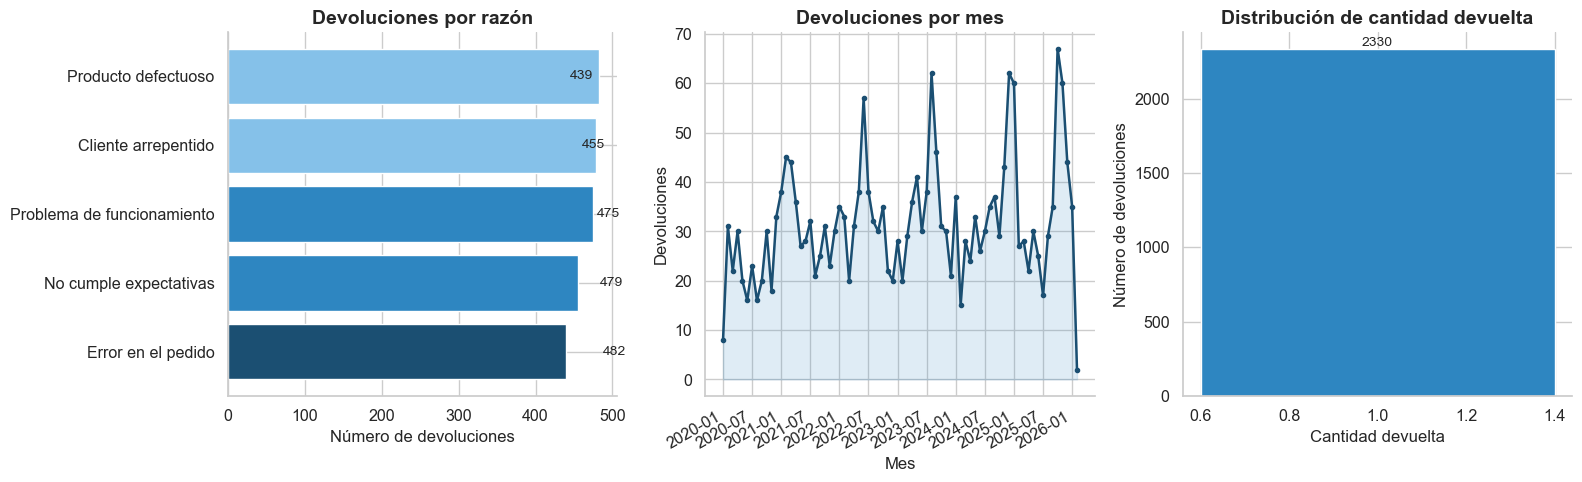

Devoluciones con cantidad > cantidad vendida: 0
✓ No hay devoluciones con cantidad excesiva.


In [68]:
# ── Distribución por razón, temporal y cantidad ───────────────────────
df_ret_full = df_return.merge(df_reasons, on='reason_id', how='left')
by_reason   = df_ret_full.groupby('reason').size().sort_values(ascending=False)

# Serie temporal mensual
df_ret_full['mes'] = df_ret_full['return_date'].dt.to_period('M')
ret_mes = df_ret_full.groupby('mes').size()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gráfico 1: por razón
colors_r = [C1 if i == 0 else C2 if i < 3 else C3 for i in range(len(by_reason))]
bars_r   = axes[0].barh(by_reason.index, by_reason.values, color=colors_r[::-1], edgecolor='white')
for i, v in enumerate(by_reason.values[::-1]):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=10)
axes[0].set_title('Devoluciones por razón', fontweight='bold')
axes[0].set_xlabel('Número de devoluciones')
axes[0].invert_yaxis()

# Gráfico 2: serie temporal
axes[1].plot(range(len(ret_mes)), ret_mes.values, color=C1, linewidth=1.8, marker='o', markersize=3)
axes[1].fill_between(range(len(ret_mes)), ret_mes.values, alpha=0.15, color=C2)
axes[1].set_title('Devoluciones por mes', fontweight='bold')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Devoluciones')
axes[1].set_xticks(range(0, len(ret_mes), 6))
axes[1].set_xticklabels([str(p) for p in ret_mes.index[::6]], rotation=30, ha='right')

# Gráfico 3: distribución de return_quantity
rq_dist = df_return['quantity'].value_counts().sort_index()
axes[2].bar(rq_dist.index, rq_dist.values, color=C2, edgecolor='white')
for k, v in zip(rq_dist.index, rq_dist.values):
    axes[2].text(k, v + 5, str(v), ha='center', va='bottom', fontsize=10)
axes[2].set_title('Distribución de cantidad devuelta', fontweight='bold')
axes[2].set_xlabel('Cantidad devuelta')
axes[2].set_ylabel('Número de devoluciones')

plt.tight_layout()
plt.savefig('graficos/eda_devoluciones.png', dpi=150, bbox_inches='tight')
plt.show()

# Verificar cantidades excesivas
df_check_ret = df_return.merge(
    df_sale_item[['sale_item_id', 'quantity']].rename(columns={'quantity': 'qty_vendida'}),
    on='sale_item_id', how='left'
)
exceso = df_check_ret[df_check_ret['quantity'] > df_check_ret['qty_vendida']]
print(f'Devoluciones con cantidad > cantidad vendida: {len(exceso)}')
if len(exceso) == 0:
    print('✓ No hay devoluciones con cantidad excesiva.')

---
## Sección 7 — Análisis de tiendas y geografía (`store` + `city_zone`)

In [69]:
df_store    = pd.read_sql('SELECT * FROM store', engine)
df_cityzone = pd.read_sql('SELECT * FROM city_zone', engine)

print(f'Tiendas: {len(df_store)}   Zonas: {len(df_cityzone)}')
print()

# Integridad: todas las tiendas tienen zona
df_store['postal_norm'] = df_store['postal_code'].str.strip().str.zfill(5)
sin_zona = df_store[~df_store['postal_norm'].isin(df_cityzone['postal_code'])]
print(f'Tiendas sin zona geográfica: {len(sin_zona)}')
if len(sin_zona) == 0:
    print('✓ Todas las tiendas tienen zona geográfica asignada.')

display(df_store[['store_id', 'name', 'postal_code', 'city']].head(5))

Tiendas: 20   Zonas: 42

Tiendas sin zona geográfica: 0
✓ Todas las tiendas tienen zona geográfica asignada.


,store_id,name,postal_code,city
0,1,Store Retiro,28009,Madrid
1,2,Store Salamanca,28001,Madrid
2,3,Store Chamartín,28016,Madrid
3,4,Store La Latina,28005,Madrid
4,5,Store Sol,28013,Madrid


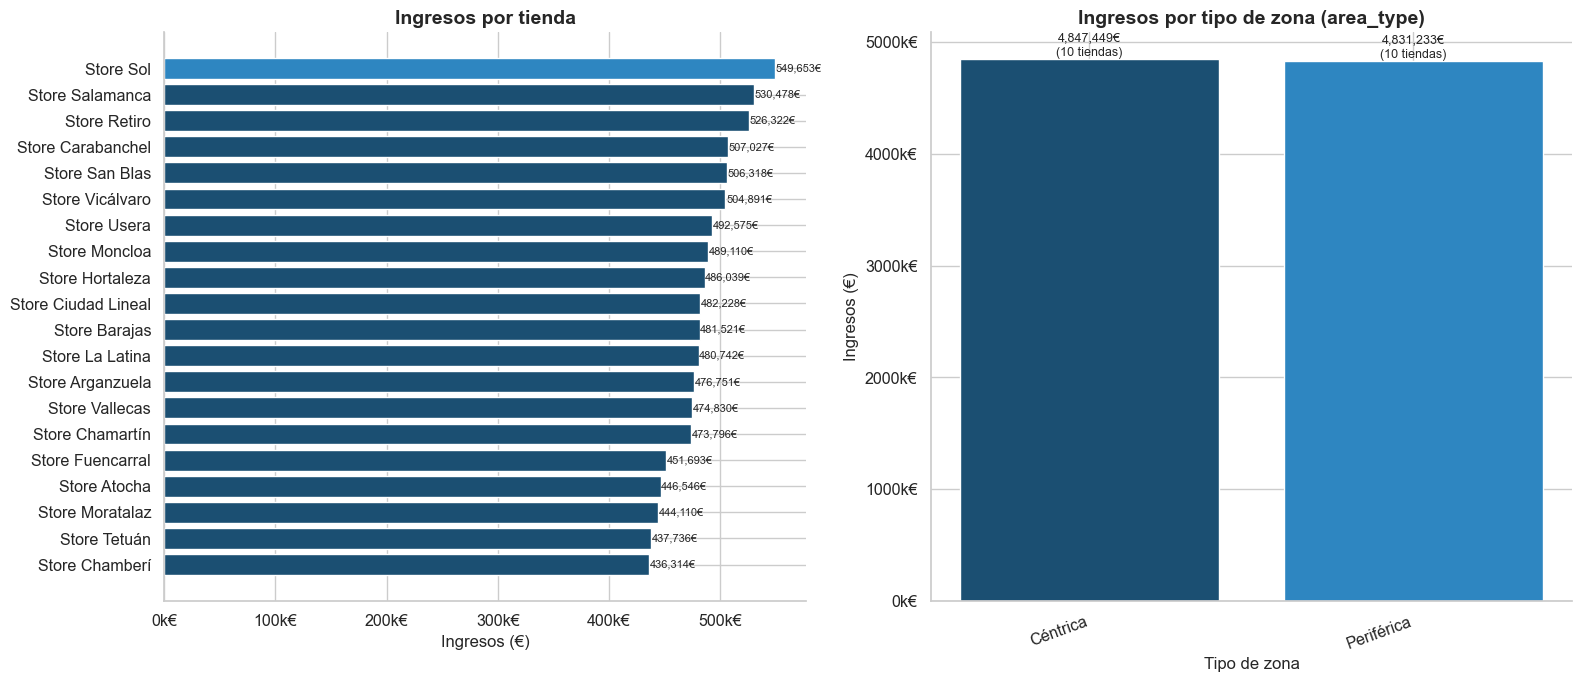


Columnas de city_zone: ['postal_code', 'district', 'area_type', 'zone_orientation', 'city_code', 'city']

Resumen por tipo de zona:
             ingresos  tiendas
area_type                     
Céntrica   4847448.81       10
Periférica 4831232.86       10


In [70]:
# ── Ventas por tienda y por zona ──────────────────────────────────────
# city_zone tiene: postal_code, district, area_type, zone_orientation, city_code, city
# Usamos 'district' para enriquecer cada tienda y 'area_type' para agrupación amplia

ventas_tienda = (
    df_sale.groupby('store_id')
    .agg(n_ventas=('sale_id', 'count'), ingresos=('total', 'sum'))
    .reset_index()
    .merge(df_store[['store_id', 'name', 'postal_norm']], on='store_id')
    .merge(df_cityzone[['postal_code', 'district', 'area_type']],
           left_on='postal_norm', right_on='postal_code', how='left')
    .sort_values('ingresos', ascending=True)
)

ventas_zona = (ventas_tienda.groupby('area_type')
               .agg(ingresos=('ingresos', 'sum'), tiendas=('store_id', 'count'))
               .sort_values('ingresos', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Gráfico 1: ingresos por tienda
palette_tienda = [C1] * len(ventas_tienda)
palette_tienda[-1] = C2
axes[0].barh(ventas_tienda['name'], ventas_tienda['ingresos'],
             color=palette_tienda, edgecolor='white')
for i, v in enumerate(ventas_tienda['ingresos']):
    axes[0].text(v + 500, i, f'{v:,.0f}€', va='center', fontsize=8)
axes[0].set_title('Ingresos por tienda', fontweight='bold')
axes[0].set_xlabel('Ingresos (€)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k€'))

# Gráfico 2: ingresos por tipo de zona (area_type)
colors_zona = [PALETTE_EDA[i % len(PALETTE_EDA)] for i in range(len(ventas_zona))]
axes[1].bar(ventas_zona.index, ventas_zona['ingresos'], color=colors_zona, edgecolor='white')
for i, (zona, row) in enumerate(ventas_zona.iterrows()):
    axes[1].text(i, row['ingresos'] + 5000,
                 f'{row["ingresos"]:,.0f}€\n({int(row["tiendas"])} tiendas)',
                 ha='center', va='bottom', fontsize=9)
axes[1].set_title('Ingresos por tipo de zona (area_type)', fontweight='bold')
axes[1].set_xlabel('Tipo de zona')
axes[1].set_ylabel('Ingresos (€)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k€'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.savefig('graficos/eda_tiendas.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nColumnas de city_zone: {df_cityzone.columns.tolist()}')
print(f'\nResumen por tipo de zona:')
print(ventas_zona.to_string())

---
## Sección 8 — Análisis de ofertas (`offer` + `product_offer`)

Verificamos cuántas ofertas hay definidas, qué productos las tienen asignadas
y si realmente se aplicaron en las ventas reales.
Esto justifica la decisión de usar una fila centinela `offer_id = -1` en el DWH.

In [71]:
df_offer         = pd.read_sql('SELECT * FROM offer', engine)
df_product_offer = pd.read_sql('SELECT * FROM product_offer', engine)

print(f'Ofertas definidas: {len(df_offer)}')
display(df_offer.style.set_caption('Tabla offer — contenido completo').hide(axis='index'))
print()

# Enriquecer product_offer con nombres de producto y oferta
po_full = (
    df_product_offer
    .merge(df_product[['product_id', 'name']], on='product_id', how='left')
    .merge(df_offer[['offer_id', 'name']].rename(columns={'name': 'oferta'}), on='offer_id', how='left')
)

print(f'Asociaciones producto-oferta: {len(df_product_offer)}')
display(po_full[['product_id', 'name', 'oferta']]
    .style.set_caption('product_offer enriquecido').hide(axis='index'))

Ofertas definidas: 1


offer_id,name,description,discount_percent,start_date,end_date
1,Semana Salud,Oferta por campaña salud,10.000000,2024-05-01,2024-05-07



Asociaciones producto-oferta: 6


product_id,name,oferta
1,Tensiómetro digital,Semana Salud
2,Oxímetro de pulso,Semana Salud
3,Termómetro infrarrojo,Semana Salud
5,Monitor de glucosa,Semana Salud
15,Lámpara de fototerapia,Semana Salud
30,Monitor sueño portátil,Semana Salud


In [72]:
# ── Cruzar con sale_item: ¿se aplicó la oferta en ventas reales? ─────
n_con  = df_sale_item['offer_id'].notna().sum()
n_null = df_sale_item['offer_id'].isna().sum()
total  = len(df_sale_item)

print('Aplicación de ofertas en sale_item:')
print(f'  Líneas CON offer_id: {n_con:,} ({n_con/total*100:.3f}%)')
print(f'  Líneas SIN offer_id: {n_null:,} ({n_null/total*100:.3f}%)')

if n_con > 0:
    aplicadas = df_sale_item[df_sale_item['offer_id'].notna()].merge(
        df_offer[['offer_id', 'name', 'discount_percent']], on='offer_id', how='left'
    )
    print(f'\nOfertas aplicadas en ventas reales:')
    display(aplicadas[['sale_item_id', 'sale_id', 'product_id', 'name', 'discount_percent']]
        .style.set_caption(f'{n_con} líneas con oferta aplicada').hide(axis='index'))
print()
print('─' * 60)
print('CONCLUSIÓN:')
print(f'  Solo {n_con} de {total:,} líneas tienen offer_id ({n_con/total*100:.3f}%).')
print(f'  Las ofertas del catálogo apenas se aplicaron en ventas reales.')
print(f'  → ETL: offer_id NULL → FK a fila centinela offer_id=-1 ("Sin oferta")')
print(f'  → Las {n_con} líneas con oferta real se mapean directamente a offer_id=1.')

Aplicación de ofertas en sale_item:
  Líneas CON offer_id: 8 (0.019%)
  Líneas SIN offer_id: 42,547 (99.981%)

Ofertas aplicadas en ventas reales:


sale_item_id,sale_id,product_id,name,discount_percent
10332,4137,5,Semana Salud,10.000000
10987,4403,3,Semana Salud,10.000000
21846,8715,1,Semana Salud,10.000000
22613,9037,1,Semana Salud,10.000000
24587,9831,3,Semana Salud,10.000000
26073,10429,15,Semana Salud,10.000000
32543,13009,2,Semana Salud,10.000000
32544,13009,30,Semana Salud,10.000000



────────────────────────────────────────────────────────────
CONCLUSIÓN:
  Solo 8 de 42,555 líneas tienen offer_id (0.019%).
  Las ofertas del catálogo apenas se aplicaron en ventas reales.
  → ETL: offer_id NULL → FK a fila centinela offer_id=-1 ("Sin oferta")
  → Las 8 líneas con oferta real se mapean directamente a offer_id=1.


---
## Sección 9 — Análisis temporal para CLTV (parámetro R_t)

En la fórmula **CLTV = Ingresos × Margen × Frecuencia × R_t**, el parámetro
**R_t** es la antigüedad del cliente en meses.

El problema: ~5.000 clientes tienen `created_at` en fechas futuras (>2025-12-30),
lo que daría `customer_age_days = 0` y por tanto **CLTV = 0** para esos clientes.

Esta sección analiza el impacto y documenta la solución.

customer_age_days calculado desde created_at (ref: 2025-12-30):
count   5750.00
mean     248.80
std      896.50
min      -98.00
25%      -98.00
50%      -98.00
75%      -96.00
max     2919.00
Name: age_days_raw, dtype: float64

Clientes con age_days ≤ 0 (created_at futura): 5,000


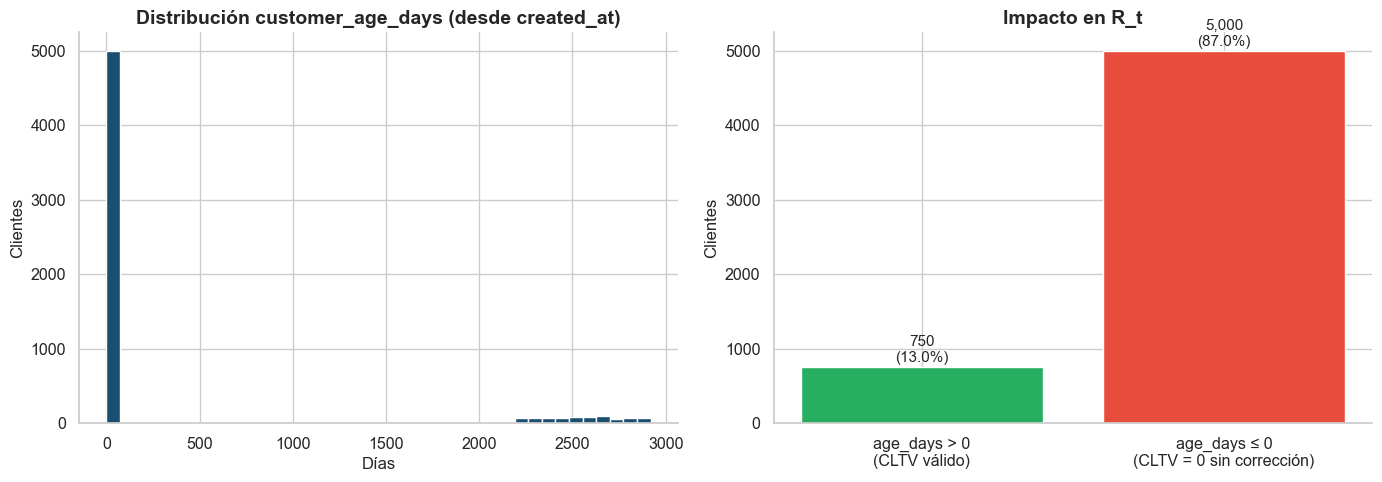

In [73]:
# ── Calcular customer_age_days desde created_at ───────────────────────
FECHA_REF = pd.Timestamp('2025-12-30')

df_age = df_customer[['customer_id', 'created_at']].copy()
df_age['age_days_raw'] = (FECHA_REF - df_age['created_at']).dt.days

n_cero_neg = (df_age['age_days_raw'] <= 0).sum()
print(f'customer_age_days calculado desde created_at (ref: {FECHA_REF.date()}):')
print(df_age['age_days_raw'].describe().round(1))
print(f'\nClientes con age_days ≤ 0 (created_at futura): {n_cero_neg:,}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de age_days (todos)
axes[0].hist(df_age['age_days_raw'].clip(lower=0), bins=40, color=C1, edgecolor='white')
axes[0].set_title('Distribución customer_age_days (desde created_at)', fontweight='bold')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Clientes')

# Impacto: clientes con age=0 vs con age>0
cats   = ['age_days > 0\n(CLTV válido)', 'age_days ≤ 0\n(CLTV = 0 sin corrección)']
conts  = [len(df_age) - n_cero_neg, n_cero_neg]
axes[1].bar(cats, conts, color=[C5, C4], edgecolor='white')
for i, v in enumerate(conts):
    axes[1].text(i, v + 30, f'{v:,}\n({v/len(df_age)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11)
axes[1].set_title('Impacto en R_t', fontweight='bold')
axes[1].set_ylabel('Clientes')

plt.tight_layout()
plt.savefig('graficos/eda_rt_age_days.png', dpi=150, bbox_inches='tight')
plt.show()

Clientes con created_at futura:              5,000
De ellos, con ≥1 venta real en la BD:        5,000

Estadísticas de R_t (meses) corregido:
count   5750.00
mean      33.01
std       27.62
min        0.03
25%        3.87
50%       29.87
75%       47.73
max       97.30
Name: age_days_final, dtype: float64

Clientes con R_t = 0 tras corrección: 0


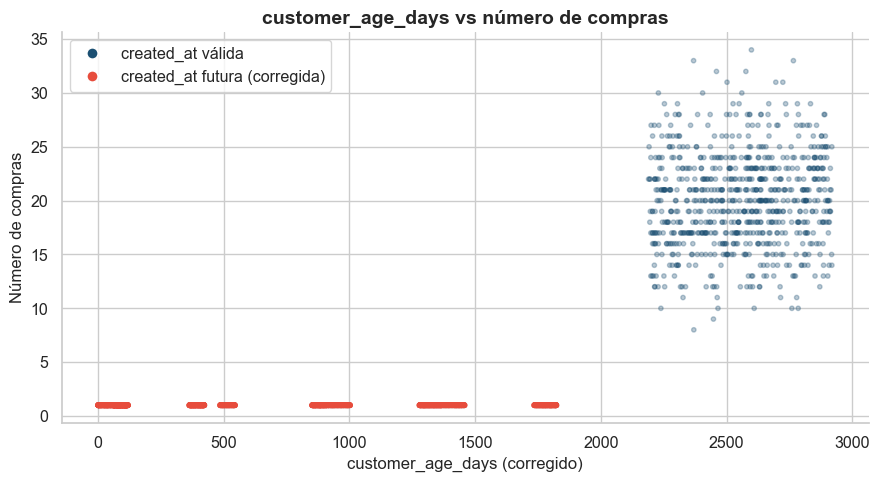

In [74]:
# ── ¿Los clientes con created_at futura tienen ventas reales? ────────
clientes_futuros = df_age[df_age['age_days_raw'] <= 0]['customer_id'].tolist()

ventas_futuros = df_sale[df_sale['customer_id'].isin(clientes_futuros)]

print(f'Clientes con created_at futura:              {len(clientes_futuros):,}')
print(f'De ellos, con ≥1 venta real en la BD:        {ventas_futuros["customer_id"].nunique():,}')
print()

# Calcular age_days desde primera compra (alternativa correcta)
primera_compra = (df_sale.groupby('customer_id')['sale_date']
                   .min().reset_index()
                   .rename(columns={'sale_date': 'primera_compra'}))
primera_compra['primera_compra'] = pd.to_datetime(primera_compra['primera_compra'])

df_age = df_age.merge(primera_compra, on='customer_id', how='left')
df_age['age_days_corr'] = (FECHA_REF - df_age['primera_compra']).dt.days.clip(lower=1)

# Para clientes con created_at válida, usar created_at; para los otros, usar primera_compra
df_age['age_days_final'] = np.where(
    df_age['age_days_raw'] > 0,
    df_age['age_days_raw'],
    df_age['age_days_corr']
)

rt = df_age['age_days_final'] / 30
print('Estadísticas de R_t (meses) corregido:')
print(rt.describe().round(2))
print(f'\nClientes con R_t = 0 tras corrección: {(rt <= 0).sum()}')

# Scatter: age_days vs número de compras
compras_por_cliente = df_sale.groupby('customer_id').size().rename('n_compras').reset_index()
df_scatter = df_age.merge(compras_por_cliente, on='customer_id', how='left')

fig, ax = plt.subplots(figsize=(9, 5))
colores_scatter = np.where(df_scatter['age_days_raw'] <= 0, C4, C1)
ax.scatter(df_scatter['age_days_final'], df_scatter['n_compras'],
           c=colores_scatter, alpha=0.3, s=10)
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=C1, markersize=8, label='created_at válida'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=C4, markersize=8, label='created_at futura (corregida)')
]
ax.legend(handles=legend_handles)
ax.set_title('customer_age_days vs número de compras', fontweight='bold')
ax.set_xlabel('customer_age_days (corregido)')
ax.set_ylabel('Número de compras')
plt.tight_layout()
plt.savefig('graficos/eda_rt_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### Decisión documentada — R_t para CLTV

| Campo | Problema | Nº registros | Decisión |
|---|---|---|---|
| `customer.created_at` | Fechas futuras → `age_days ≤ 0` → `R_t = 0` → **CLTV = 0** | ~5.000 | Usar `first_purchase_date` como origen temporal para esos clientes; mínimo garantizado de 1 día |

> **Razonamiento:** Un cliente con fecha de alta futura aún tiene historial de compras real.
> Si usáramos `created_at` directamente, su CLTV sería cero aunque sea un cliente valioso.
> La fecha de primera compra es siempre válida (está en el rango 2020–2025).

---
## Sección 10 — Tabla maestra de decisiones de imputación

Consolidación de **todas** las decisiones tomadas a lo largo del notebook.
Esta tabla es la referencia directa para implementar el ETL en `03_etl.ipynb`.

In [75]:
# Calcular valores reales para la tabla (los N exactos encontrados en este EDA)
_n_email_null  = int(df_customer['email'].isna().sum())
_n_email_sp    = int(df_customer['email'].str.contains(r'\s', na=False).sum())
_n_fn_null     = int(df_customer['first_name'].isna().sum())
_n_phone_null  = int(df_customer['phone'].isna().sum())
_n_created_fut = int((df_customer['created_at'] > pd.Timestamp('2025-12-30')).sum())
_n_sin_coste   = int(merge_id['unit_cost'].isna().sum())
_n_cat_inv     = int((df_product['category'].str.lower().str.strip()
                        .isin([c.lower().strip() for c in df_category['name'].tolist()]) == False).sum())
_n_offer_null  = int(df_sale_item['offer_id'].isna().sum())
_n_total_disc  = int(len(discrepancias))

decisiones = [
    {'Tabla'               : 'customer',
     'Campo'              : 'email',
     'Problema'           : 'NULL',
     'Registros afectados': _n_email_null,
     'Decisión ETL'       : 'cliente_<ID>@unknown.com',
     'Impacto en DWH'     : 'dim_customer'},

    {'Tabla'               : 'customer',
     'Campo'              : 'email',
     'Problema'           : 'Espacios por apellidos compuestos',
     'Registros afectados': _n_email_sp,
     'Decisión ETL'       : 'Eliminar espacios del email',
     'Impacto en DWH'     : 'dim_customer'},

    {'Tabla'               : 'customer',
     'Campo'              : 'first_name / last_name',
     'Problema'           : 'NULL',
     'Registros afectados': _n_fn_null,
     'Decisión ETL'       : '"Desconocido"',
     'Impacto en DWH'     : 'dim_customer'},

    {'Tabla'               : 'customer',
     'Campo'              : 'phone',
     'Problema'           : 'NULL',
     'Registros afectados': _n_phone_null,
     'Decisión ETL'       : '"000000000"',
     'Impacto en DWH'     : 'dim_customer'},

    {'Tabla'               : 'customer',
     'Campo'              : 'created_at',
     'Problema'           : 'Fechas futuras >2025-12-30 → R_t = 0',
     'Registros afectados': _n_created_fut,
     'Decisión ETL'       : 'Usar first_purchase_date para customer_age_days',
     'Impacto en DWH'     : 'dim_customer, CLTV'},

    {'Tabla'               : 'central_product',
     'Campo'              : 'unit_cost',
     'Problema'           : 'NULL — producto sin coste',
     'Registros afectados': _n_sin_coste,
     'Decisión ETL'       : f'Mediana global de unit_cost ({mediana_global:.2f}€)',
     'Impacto en DWH'     : 'dim_product, fact_sales'},

    {'Tabla'               : 'product',
     'Campo'              : 'category',
     'Problema'           : 'Valor "Domótica Salud" no existe en tabla category',
     'Registros afectados': _n_cat_inv,
     'Decisión ETL'       : 'Reclasificar como "Diagnóstico" (product_id=29)',
     'Impacto en DWH'     : 'dim_product'},

    {'Tabla'               : 'sale_item',
     'Campo'              : 'offer_id',
     'Problema'           : '~100% NULL — oferta nunca aplicada',
     'Registros afectados': _n_offer_null,
     'Decisión ETL'       : 'FK → fila centinela offer_id = -1 en dim_offer',
     'Impacto en DWH'     : 'fact_sales'},

    {'Tabla'               : 'sale',
     'Campo'              : 'total',
     'Problema'           : 'Discrepancia entre total y suma de líneas',
     'Registros afectados': _n_total_disc,
     'Decisión ETL'       : 'Flag total_corrected = TRUE; usar suma de sale_item',
     'Impacto en DWH'     : 'fact_sales'},
]

df_master = pd.DataFrame(decisiones)

display(
    df_master.style
    .set_caption('Tabla maestra de decisiones de imputación — EDA Fase 1')
    .apply(lambda col: [
        'background-color: #FDFEFE' if i % 2 == 0 else 'background-color: #EBF5FB'
        for i in range(len(df_master))
    ], axis=0)
    .set_properties(**{'text-align': 'left', 'font-size': '11px'})
    .hide(axis='index')
)

Tabla,Campo,Problema,Registros afectados,Decisión ETL,Impacto en DWH
customer,email,NULL,0,cliente_@unknown.com,dim_customer
customer,email,Espacios por apellidos compuestos,98,Eliminar espacios del email,dim_customer
customer,first_name / last_name,NULL,0,"""Desconocido""",dim_customer
customer,phone,NULL,0,"""000000000""",dim_customer
customer,created_at,Fechas futuras >2025-12-30 → R_t = 0,5000,Usar first_purchase_date para customer_age_days,"dim_customer, CLTV"
central_product,unit_cost,NULL — producto sin coste,1,Mediana global de unit_cost (59.94€),"dim_product, fact_sales"
product,category,"Valor ""Domótica Salud"" no existe en tabla category",1,"Reclasificar como ""Diagnóstico"" (product_id=29)",dim_product
sale_item,offer_id,~100% NULL — oferta nunca aplicada,42547,FK → fila centinela offer_id = -1 en dim_offer,fact_sales
sale,total,Discrepancia entre total y suma de líneas,1,Flag total_corrected = TRUE; usar suma de sale_item,fact_sales


---
## Criterio de "done" para esta fase

El EDA está completo cuando:

- [x] Las 17 tablas están inventariadas con conteo de filas y NULLs
- [x] Todas las gráficas se generan sin errores
- [x] La tabla maestra de decisiones tiene los números reales rellenados
- [x] No queda ninguna anomalía sin decisión documentada
- [ ] El notebook se ejecuta de principio a fin con **Restart & Run All** sin errores

---

> **Siguiente paso:** `03_etl.ipynb` — implementar todas las transformaciones
> documentadas aquí para cargar el Data Warehouse.